# German Electricity Demand — Exploratory Data Analysis

> **Dataset**: SMARD.de hourly grid load — actual consumption vs. TSO day-ahead forecast.  
> Run `python -m src.data.cleaner` before opening this notebook to populate `data/processed/`.

## 1 · Overview

In [1]:
import sys
print(sys.executable)

c:\Users\Utkarsh Rai\german-electricity-demand-forecasting\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

ROOT      = Path('..').resolve()
processed = ROOT / 'data' / 'processed'

actual   = pd.read_parquet(processed / 'actual_load.parquet')
forecast = pd.read_parquet(processed / 'forecast_load.parquet')

SEP = '─' * 55
for name, df in [('actual_load', actual), ('forecast_load', forecast)]:
    print(SEP)
    print(f'  {name}')
    print(SEP)
    print(f'  shape  : {df.shape}')
    print(f'  dtype  : {df.iloc[:, 0].dtype}')
    print(f'  span   : {df.index.min()}  →  {df.index.max()}')
    print()
    display(df.head(3))
    print()

───────────────────────────────────────────────────────
  actual_load
───────────────────────────────────────────────────────
  shape  : (56592, 1)
  dtype  : float64
  span   : 2020-01-01 00:00:00  →  2026-06-15 23:00:00



,actual_load
timestamp,
2020-01-01 00:00:00,43500.50
2020-01-01 01:00:00,42598.75
2020-01-01 02:00:00,41463.75



───────────────────────────────────────────────────────
  forecast_load
───────────────────────────────────────────────────────
  shape  : (56592, 1)
  dtype  : float64
  span   : 2020-01-01 00:00:00  →  2026-06-15 23:00:00



,forecast_load
timestamp,
2020-01-01 00:00:00,45471.5
2020-01-01 01:00:00,43471.5
2020-01-01 02:00:00,42555.5


## 2 · Load over Time

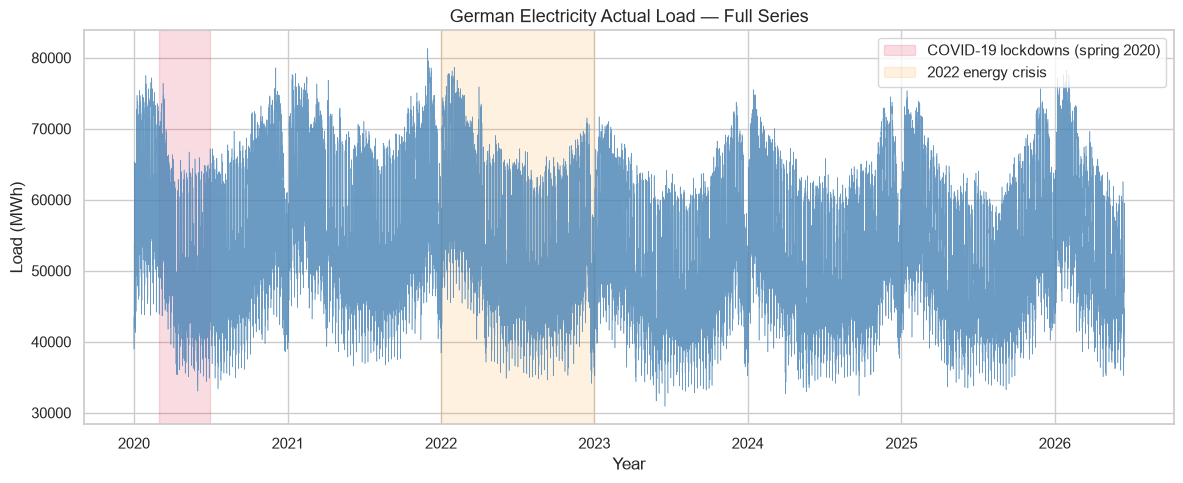

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(actual.index, actual['actual_load'], linewidth=0.4, color='steelblue', alpha=0.8)
ax.set_title('German Electricity Actual Load — Full Series', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Load (MWh)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'),
           alpha=0.15, color='crimson', label='COVID-19 lockdowns (spring 2020)')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.12, color='darkorange', label='2022 energy crisis')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3 · Distribution

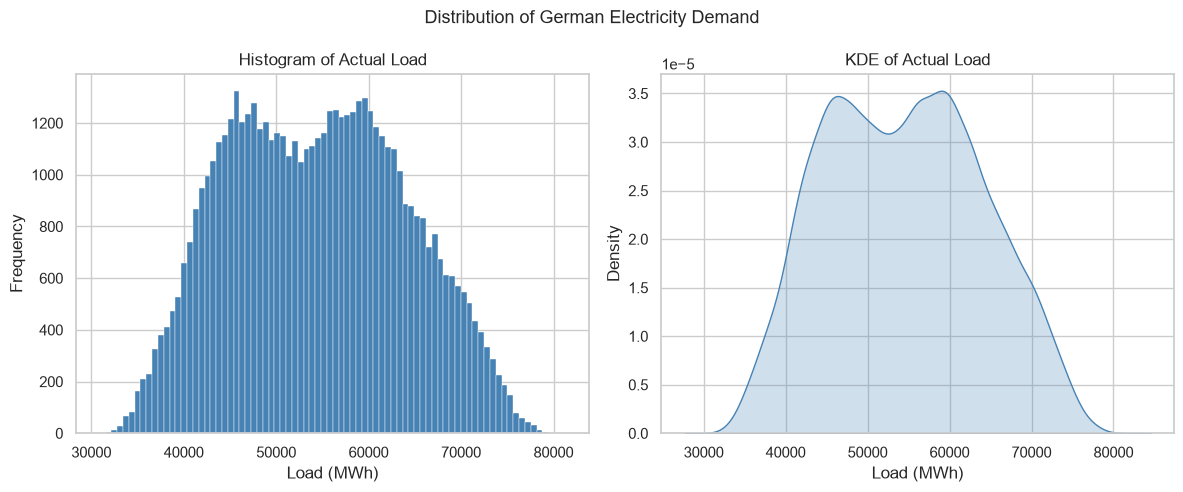

count    56592.0
mean     54427.2
std       9582.7
min      30902.8
25%      46616.4
50%      54385.5
75%      61637.1
max      81319.5
Name: actual_load, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(actual['actual_load'].dropna(), bins=80,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Histogram of Actual Load')
axes[0].set_xlabel('Load (MWh)')
axes[0].set_ylabel('Frequency')

sns.kdeplot(actual['actual_load'].dropna(), ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE of Actual Load')
axes[1].set_xlabel('Load (MWh)')

plt.suptitle('Distribution of German Electricity Demand', fontsize=13)
plt.tight_layout()
plt.show()

print(actual['actual_load'].describe().round(1))

## 4 · Seasonality Profiles

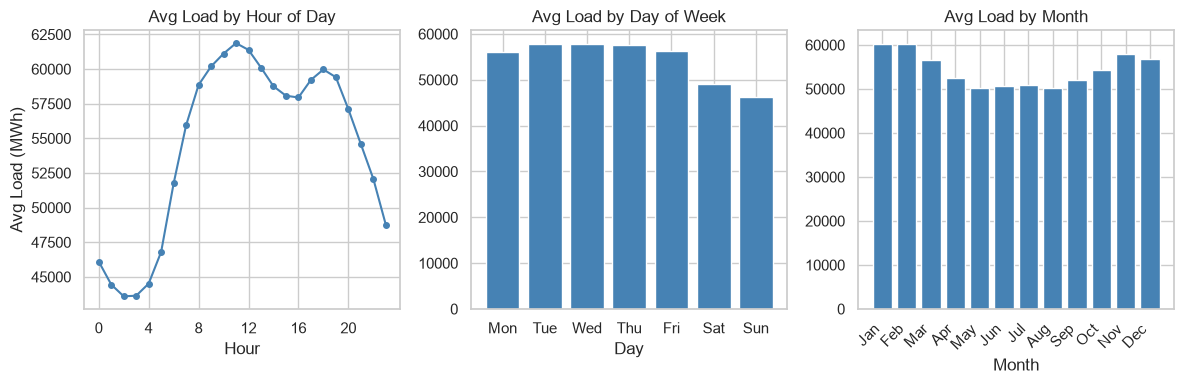

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ── Hour of day ───────────────────────────────────────────────────────────────
hourly = actual['actual_load'].groupby(actual.index.hour).mean()
axes[0].plot(hourly.index, hourly.values, marker='o', markersize=4, color='steelblue')
axes[0].set_title('Avg Load by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Load (MWh)')
axes[0].set_xticks(range(0, 24, 4))

# ── Day of week ───────────────────────────────────────────────────────────────
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = actual['actual_load'].groupby(actual.index.dayofweek).mean()
axes[1].bar(range(7), daily.values, color='steelblue')
axes[1].set_title('Avg Load by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)

# ── Month ─────────────────────────────────────────────────────────────────────
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = actual['actual_load'].groupby(actual.index.month).mean()
axes[2].bar(range(1, 13), monthly.values, color='steelblue')
axes[2].set_title('Avg Load by Month')
axes[2].set_xlabel('Month')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5 · Autocorrelation

Strong spikes at **lag 24** (daily cycle) and **lag 168** (weekly cycle = 7 × 24 h) are the key structural signals any model must replicate.

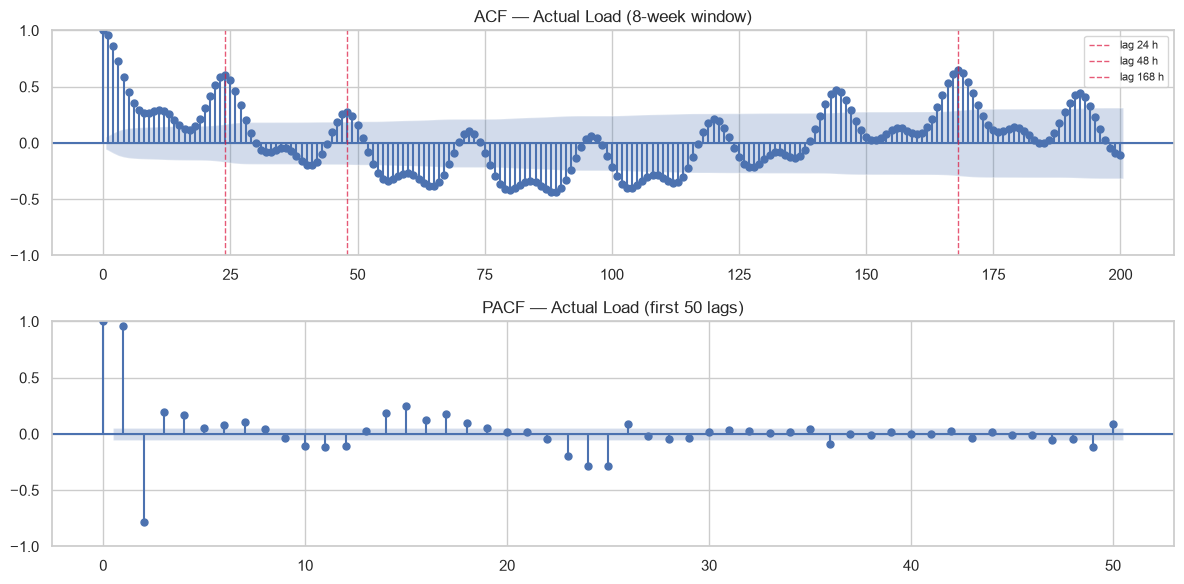

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 8-week window — long enough to capture lag-168 without being slow
sample = actual['actual_load'].dropna().iloc[-8 * 7 * 24:]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(sample,  lags=200, ax=axes[0], title='ACF — Actual Load (8-week window)')
plot_pacf(sample, lags=50,  ax=axes[1], title='PACF — Actual Load (first 50 lags)')

for lag in [24, 48, 168]:
    axes[0].axvline(lag, color='crimson', linestyle='--',
                    alpha=0.7, linewidth=1, label=f'lag {lag} h')
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6 · Seasonal Decomposition

Additive decomposition on the last 90 days with `period=24` to isolate the intra-day component.  
The trend component will also reveal longer-term drift (e.g. the 2022 demand reduction).

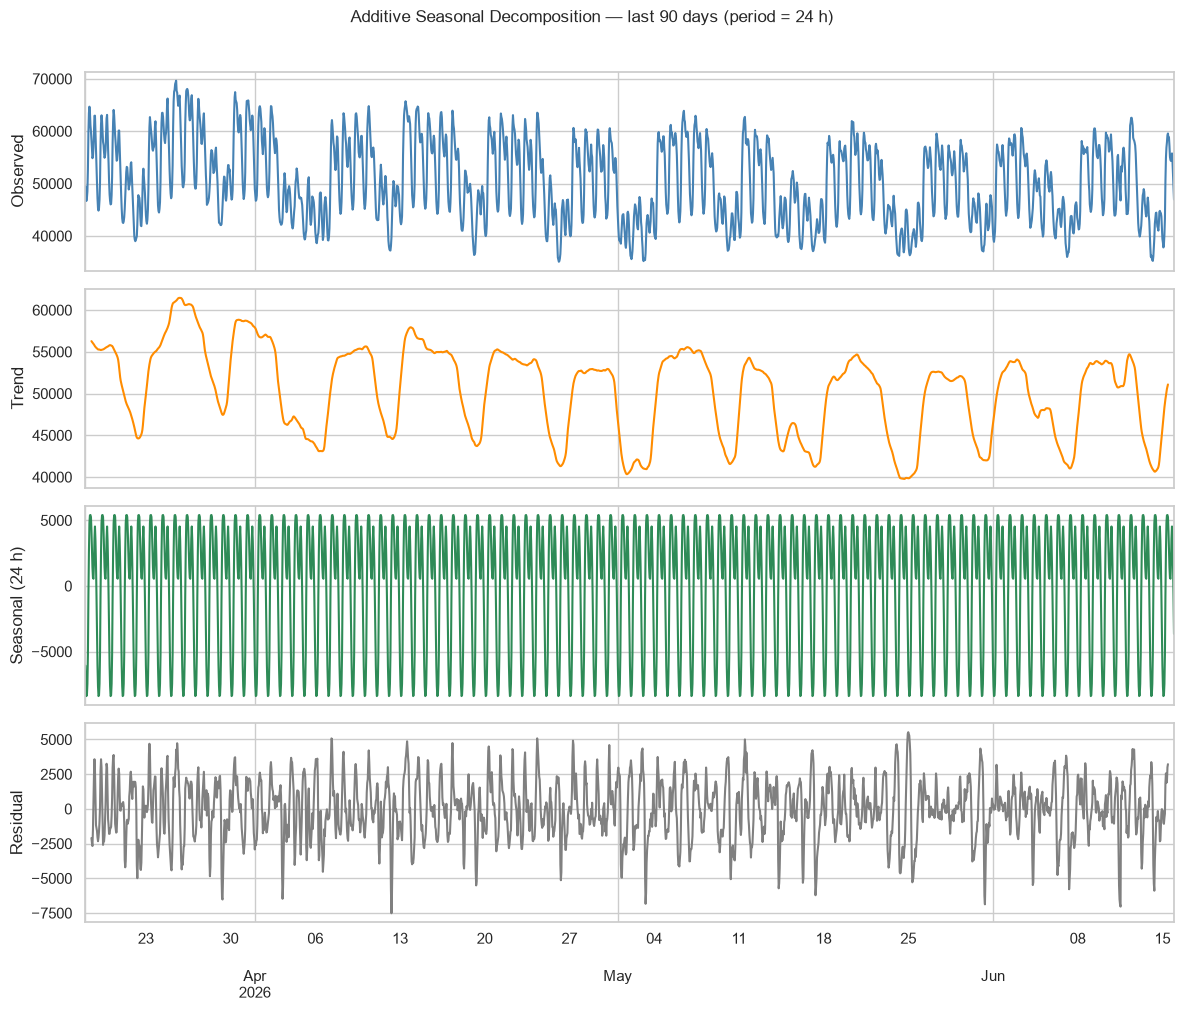

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

slice_90d = actual['actual_load'].dropna().iloc[-90 * 24:]
decomp    = seasonal_decompose(slice_90d, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

slice_90d.plot(ax=axes[0], color='steelblue');    axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1], color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='seagreen'); axes[2].set_ylabel('Seasonal (24 h)')
decomp.resid.plot(ax=axes[3], color='grey');       axes[3].set_ylabel('Residual')

for ax in axes:
    ax.set_xlabel('')

fig.suptitle('Additive Seasonal Decomposition — last 90 days (period = 24 h)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 7 · Actual vs TSO Forecast

The TSO (ENTSOE/50Hertz/Amprion/TenneT/TransnetBW composite) publishes a day-ahead load forecast.  
Its MAPE is our **primary baseline benchmark**.

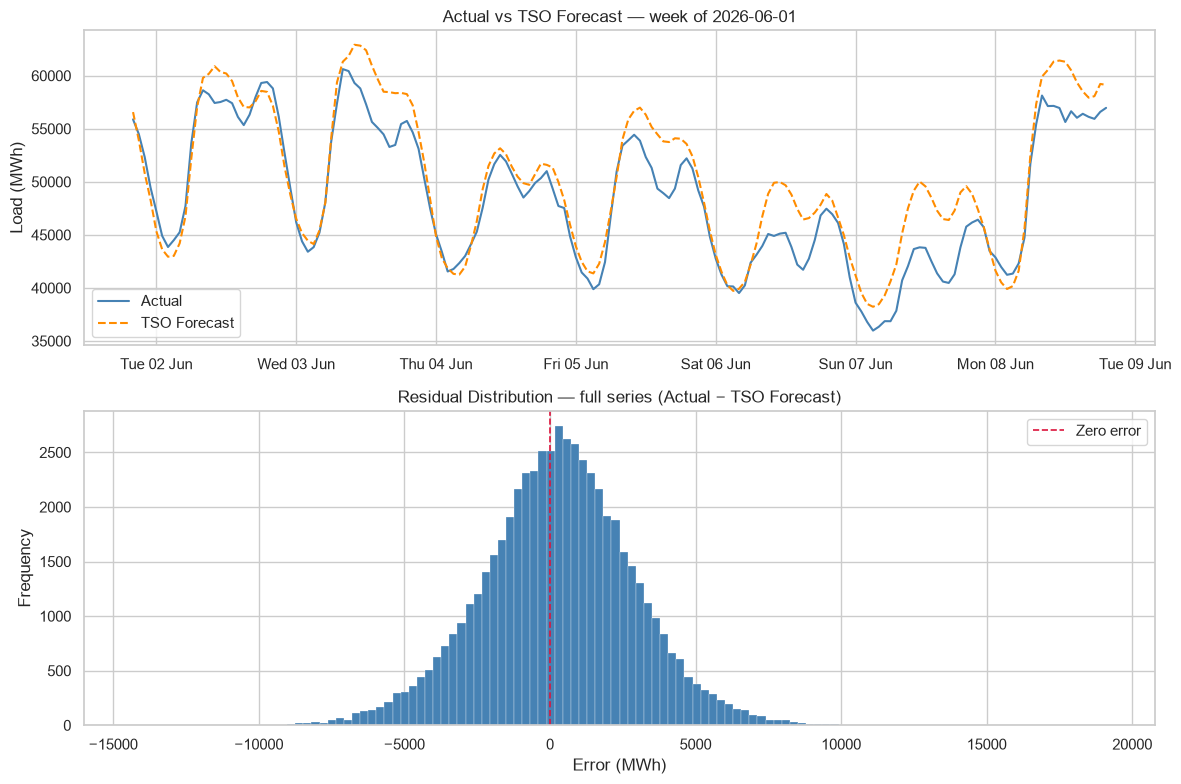

TSO Forecast  MAE  :    2,048.6 MWh
TSO Forecast  MAPE :       3.80%   ← benchmark to beat


In [8]:
# Pick one full Mon–Sun roughly 1 year before end of series
week_start = actual.index[actual.index.dayofweek == 0][-52]
week_end   = week_start + pd.Timedelta(hours=7 * 24 - 1)

wa = actual.loc[week_start:week_end, 'actual_load']
wf = forecast.loc[week_start:week_end, 'forecast_load']

# Full-series residuals for the distribution panel
common_idx = actual.index.intersection(forecast.index)
residuals  = (actual.loc[common_idx, 'actual_load']
              - forecast.loc[common_idx, 'forecast_load'])

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ── Top: sample week ──────────────────────────────────────────────────────────
axes[0].plot(wa.index, wa.values, label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(wf.index, wf.values, label='TSO Forecast', color='darkorange',
             linewidth=1.5, linestyle='--')
axes[0].set_title(f'Actual vs TSO Forecast — week of {week_start.date()}', fontsize=12)
axes[0].set_ylabel('Load (MWh)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
axes[0].legend()

# ── Bottom: residual distribution (full series) ───────────────────────────────
axes[1].hist(residuals.dropna(), bins=120, color='steelblue',
             edgecolor='white', linewidth=0.2)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.2, label='Zero error')
axes[1].set_title('Residual Distribution — full series (Actual − TSO Forecast)', fontsize=12)
axes[1].set_xlabel('Error (MWh)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Benchmark metrics ─────────────────────────────────────────────────────────
mae  = residuals.abs().mean()
mape = (residuals.abs() / actual.loc[common_idx, 'actual_load']).mean() * 100
print(f'TSO Forecast  MAE  : {mae:>10,.1f} MWh')
print(f'TSO Forecast  MAPE : {mape:>10.2f}%   ← benchmark to beat')

## Key Findings

1. **Daily cycle dominates**: load peaks mid-morning (~09:00) and early evening (~18:00–20:00) with a swing of roughly 20,000 MWh; the lag-24 ACF spike is the single strongest repeating pattern in the series.
2. **Weekly rhythm is strong**: weekday demand runs ~10–15 % above Saturday and ~20 % above Sunday — visible in both the day-of-week profile and the lag-168 ACF spike (7 × 24 h).
3. **Winter loading is ~10 % above summer**: December–February averages are the highest of the year, driven by heating demand, shorter daylight hours, and sustained industrial activity.
4. **Demand shocks are visible**: spring 2020 shows a sustained ~5–8 % drop from COVID-19 lockdowns; 2022 shows a structurally lower baseline as German industry curtailed consumption in response to record gas prices — both periods are atypical and may need to be down-weighted in training.
5. **TSO benchmark MAPE ≈ 3.79 %**: the composite day-ahead forecast from the transmission system operators is already strong; beating it will require well-engineered weather, calendar, and holiday features rather than pure autoregressive structure.